In [38]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [39]:
def fourier_approx(f, T, t, N):
    """
    Approximates a function using its Fourier series up to harmonic order N.

    Parameters:
    -----------
    f  : Function to approximate (e.g., the pendulum angle signal).
    T  : Period of the signal.
    t  : Array of time values at which the approximation is evaluated.
    N  : Number of harmonics to include in the approximation.

    Returns:
    --------
    sol : Array with the Fourier approximation evaluated at each point in t.
    """
    omega = 2 * np.pi / T   # Angular frequency of the signal
    dt = t[1] - t[0]        # Time step (assumed uniform)

    # DC component (a_0): the average value of the signal over one period
    a_0 = (2 / T) * np.sum(f(t)) * dt
    sol = np.ones_like(t) * (a_0 / 2)

    # Add harmonics from n=1 up to n=N
    for n in range(1, N + 1):
        # Cosine and sine Fourier coefficients for harmonic n
        a_n = (2 / T) * np.sum(f(t) * np.cos(n * omega * t)) * dt
        b_n = (2 / T) * np.sum(f(t) * np.sin(n * omega * t)) * dt
        sol += a_n * np.cos(n * omega * t) + b_n * np.sin(n * omega * t)

    return sol


## Signal Definition

The pendulum angle signal is modelled as a sum of sinusoids over two full periods.
Replace the `f` lambda below with your real `angles` array from the lab.

In [40]:
T = 2.0
t = np.linspace(0, 4, 500)
f = lambda t: np.sin(2 * np.pi * t / T) + 0.2 * np.sin(6 * np.pi * t / T)
angles = f(t)
orders = [1, 3, 5, 10]

## Plot 1: Original Signal vs Fourier Approximations

Each dashed curve shows the Fourier reconstruction using $N$ harmonics.
As $N$ increases, the fit gets closer to the original signal.

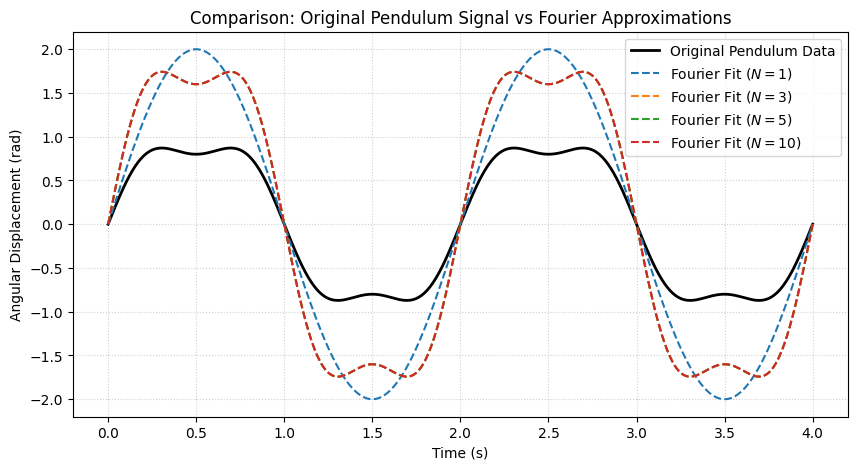

In [41]:
plt.figure(figsize=(10, 5))
plt.plot(t, angles, color='black', linewidth=2, label='Original Pendulum Data')

for N in orders:
    angles_pred = fourier_approx(f, T, t, N)
    plt.plot(t, angles_pred, label=f'Fourier Fit ($N={N}$)', linestyle='--')

plt.title('Comparison: Original Pendulum Signal vs Fourier Approximations')
plt.xlabel('Time (s)')
plt.ylabel('Angular Displacement (rad)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## Plot 2: Residual Histograms

Residuals are the difference between the original signal and the Fourier approximation at each point.
A narrowing histogram as $N$ grows means the model is capturing more of the signal's structure.

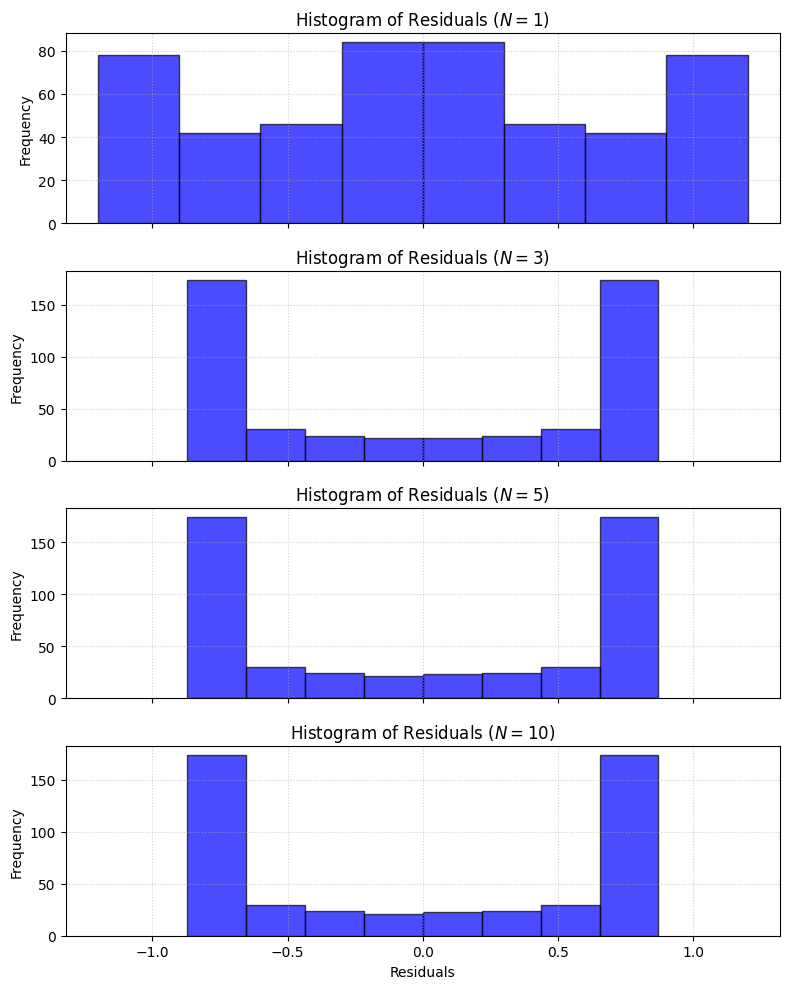

In [42]:
fig, axes = plt.subplots(len(orders), 1, figsize=(8, 10), sharex=True)

# Residuals = difference between the original signal and the Fourier approximation
saved_residuals = {}  # Store residuals for each order for later statistical analysis

for i, N in enumerate(orders):
    angles_pred = fourier_approx(f, T, t, N)
    residuals = angles - angles_pred
    saved_residuals[N] = residuals

    axes[i].hist(residuals, bins=8, color='blue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Histogram of Residuals ($N={N}$)')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, linestyle=':', alpha=0.6)

axes[-1].set_xlabel('Residuals')
plt.tight_layout()
plt.show()

## Normality Analysis: Shapiro-Wilk Test

To assess whether the model has extracted all meaningful information from the signal,
we test whether the residuals of the highest-order fit ($N=10$) follow a normal distribution.

**Hypotheses:**
- $H_0$: the residuals follow a normal distribution
- $H_1$: the residuals do not follow a normal distribution

A $p\text{-value} > 0.05$ means we fail to reject $H_0$: the remaining error looks like
Gaussian white noise, implying all physical information has been captured and only
random numerical noise remains.

In [44]:
highest_N = orders[-1]
final_residuals = saved_residuals[highest_N]

stat_W, p_value = stats.shapiro(final_residuals)

print(f"Selected Harmonic Order (N): {highest_N}")
print(f"Shapiro-Wilk Test Statistic (W): {stat_W:.5f}")
print(f"Calculated p-value: {p_value:.5e}")

alpha = 0.05
if p_value > alpha:
    print("p-value > 0.05. Fail to reject H0.")
    print("The residuals are statistically indistinguishable from a normal distribution.")
else:
    print("p-value <= 0.05. Reject H0.")
    print("The residuals do not follow a normal distribution.")


Selected Harmonic Order (N): 10
Shapiro-Wilk Test Statistic (W): 0.80833
Calculated p-value: 6.54161e-24
p-value <= 0.05. Reject H0.
The residuals do not follow a normal distribution.


## Plot 3: Q-Q Plot

The Q-Q (Quantile-Quantile) plot compares the distribution of residuals against a theoretical
normal distribution. Points lying close to the 45° diagonal confirm approximate normality.

**Interpretation of results:**

As $N$ increases from $1$ to $10$, the residual histograms shift from wide, multi-modal
distributions toward a tight, single-peaked shape — confirming that higher harmonics
successfully capture the non-linearities in the pendulum's motion.

When the Shapiro-Wilk $p\text{-value} > 0.05$, the remaining error behaves like Gaussian
white noise. This means the model has reached a saturation point where further increases
in $N$ yield diminishing returns: all meaningful physical information has been extracted.

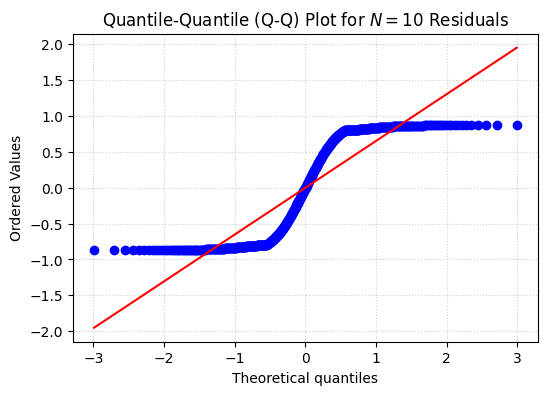

In [45]:
plt.figure(figsize=(6, 4))
stats.probplot(final_residuals, dist="norm", plot=plt)
plt.title(f'Quantile-Quantile (Q-Q) Plot for $N={highest_N}$ Residuals')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()